# OPERA RTC-S1 Time-Series — Oosterweel Construction Works, Antwerp

This notebook demonstrates the full workflow for **OPERA Radiometric
Terrain-Corrected (RTC)** SAR backscatter analysis from Sentinel-1 over the
**Oosterweel Link construction site** in Antwerp, Belgium.

## Workflow

1. **Define AOI & temporal range** — bounding box around the construction zone
2. **Choose archive** — Terrascope, NASA/ASF, or automatic fallback
3. **Search** — query the STAC catalogue for available passes
4. **Coverage analysis** — inspect spatial coverage per pass, filter by threshold
5. **Load & mosaic** — stream data pass-by-pass (memory-efficient)
6. **Visualise** — composites, time-series, animated GIF

## RTC false-colour convention (ASF/HyP3)
- **R** = sqrt(VV) &ensp;(amplitude range 0.14 – 0.52)
- **G** = sqrt(VH) &ensp;(amplitude range 0.05 – 0.259)
- **B** = sqrt(VV) &ensp;(same as R)

In [1]:
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from rs_tools.config import BoundingBox, SearchConfig
from rs_tools.search import search_archive
from rs_tools.datasets.catalog import get as get_dataset
from rs_tools.datasets.coverage import (
    summarize_search_results,
    print_coverage_report,
    filter_by_coverage,
    records_to_items,
)
from rs_tools.datasets.loader import load_items, setup_terrascope_auth, LoadedItem
from rs_tools.visualization.rtc_composite import rtc_composite
from rs_tools.visualization.scalebar import add_scalebar
from rs_tools.visualization.animation import save_timeseries_gif_lazy
from rs_tools.visualization.overlays import fetch_roads, overlay_roads, annotate_location

## 1. Define area of interest & temporal range

The Oosterweel Link is a major infrastructure project involving tunnels under the
Scheldt river connecting the left and right banks of Antwerp.

In [2]:
# Area of interest
bbox_oosterweel = BoundingBox(west=4.30, south=51.17, east=4.48, north=51.27)

# Full Sentinel-1 mission period (OPERA data available from ~Oct 2021)
START_DATE = "2014-10-01"
END_DATE   = "2026-03-24"

print(f"AOI:        {bbox_oosterweel}")
print(f"Time range: {START_DATE} → {END_DATE}")

AOI:        BoundingBox(west=4.3, south=51.17, east=4.48, north=51.27)
Time range: 2014-10-01 → 2026-03-24


## 2. AOI overview map

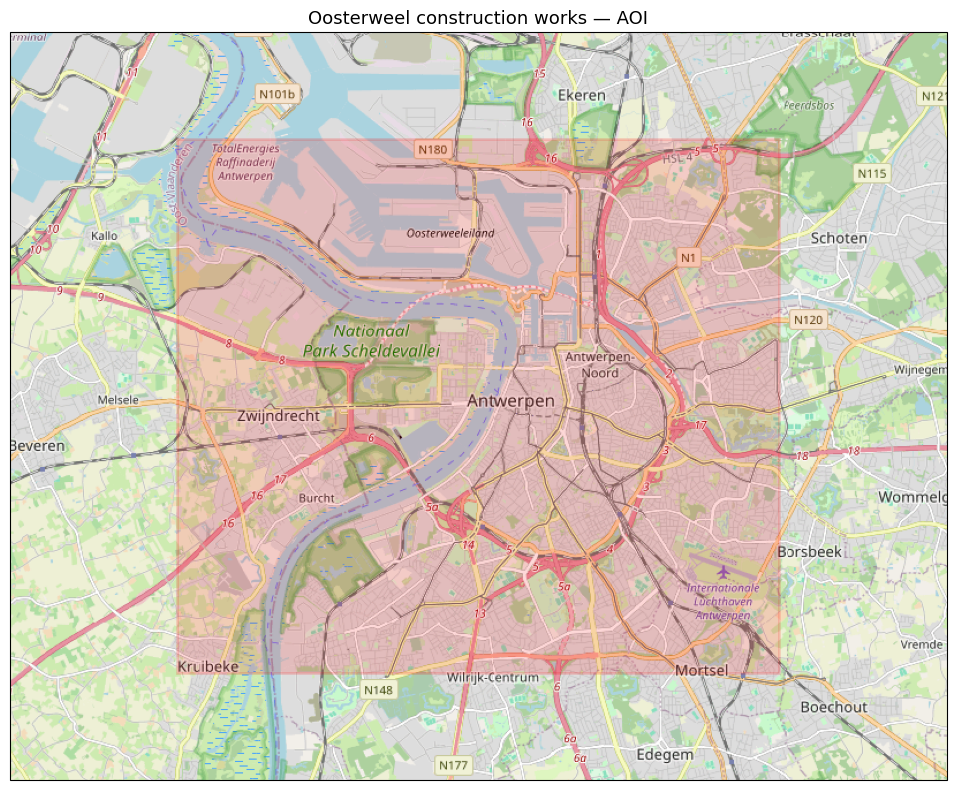

In [3]:
import cartopy.crs as ccrs
import matplotlib.patches as mpatches
from cartopy.io.img_tiles import OSM

osm_tiles = OSM()
fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={"projection": osm_tiles.crs})
ax.set_extent([bbox_oosterweel.west - 0.05, bbox_oosterweel.east + 0.05,
               bbox_oosterweel.south - 0.02, bbox_oosterweel.north + 0.02],
              crs=ccrs.PlateCarree())
ax.add_image(osm_tiles, 12)
rect = mpatches.Rectangle(
    (bbox_oosterweel.west, bbox_oosterweel.south),
    bbox_oosterweel.east - bbox_oosterweel.west,
    bbox_oosterweel.north - bbox_oosterweel.south,
    transform=ccrs.PlateCarree(), linewidth=2,
    edgecolor="red", facecolor="red", alpha=0.15,
)
ax.add_patch(rect)
ax.set_title("Oosterweel construction works — AOI", fontsize=13)
plt.tight_layout()
plt.show()

## 3. Choose archive

OPERA RTC-S1 data is available from multiple archives. Set `ARCHIVE` below
to control which source is queried:

| `ARCHIVE` value | Description |
|:---:|:---|
| `"terrascope"` | **Terrascope STAC** (VITO). Fast from Europe, uses local mounts on VITO servers. |
| `"nasa"` | **NASA ASF DAAC**. Original source; uses S3 on AWS, HTTPS elsewhere. |
| `None` | **Automatic fallback** — tries archives in catalog priority order (Terrascope → NASA) and uses the first one that returns results. |

On a **VITO server**, Terrascope data can be streamed from the local `/data/MTDA`
mount (fastest) or via HTTPS (if the local mount is unavailable on that node).
The library detects this automatically.

In [4]:
# ── Archive selection ─────────────────────────────────────────────────────
#   "terrascope"  — Terrascope STAC only
#   "nasa"        — NASA ASF DAAC only
#   None          — automatic fallback (tries Terrascope first, then NASA)
ARCHIVE = "terrascope"

# Show which collections this dataset maps to in each archive
ds_info = get_dataset("OPERA_RTC_S1")
print(f"Dataset:  {ds_info.name}")
print(f"Product:  {ds_info.description}")
print(f"Resolution: {ds_info.spatial_resolution}, repeat cycle: {ds_info.temporal_resolution}")
print(f"\nAvailable archives:")
for arch, colls in ds_info.archive_collections.items():
    marker = " ← selected" if arch == ARCHIVE else ""
    print(f"  {arch:12s} → {', '.join(colls)}{marker}")

Dataset:  OPERA RTC-S1
Product:  OPERA Radiometric Terrain-Corrected SAR backscatter from Sentinel-1.
Resolution: 30 m, repeat cycle: 6-12 days

Available archives:
  terrascope   → opera-s1-rtc-v1 ← selected
  nasa         → OPERA_L2_RTC-S1_V1_1


## 4. Search the catalogue

Query the STAC catalogue for all available passes over the full time range.
This does **not** download any pixel data — only lightweight metadata.

In [6]:
# Search for all available STAC items
collections = ds_info.archive_collections[ARCHIVE]
config = SearchConfig(
    start_date=START_DATE,
    end_date=END_DATE,
    bbox=bbox_oosterweel,
    collections=collections,
    limit=9000000,
)
items = search_archive(ARCHIVE, config)
print(f"Search returned {len(items)} STAC items (burst granules)")

Search returned 1450 STAC items (burst granules)


## 5. Coverage analysis

Group the raw burst granules by satellite pass (same track + same date) and
compute the **spatial coverage** — what percentage of the AOI bounding box is
covered by the union of all burst footprints in that pass.

This lets you decide:
- **Which coverage threshold** to apply (e.g. keep only passes with ≥ 80% coverage)
- **Which orbit direction** to keep (ascending, descending, or both)
- **Which tracks** to focus on

In [7]:
# Build a per-pass coverage summary (no pixel data loaded yet)
records = summarize_search_results(items, bbox_oosterweel)
print_coverage_report(records)

----------------------------------------------------------------------------------
   #  Date          UTC Time    Platform        Orbit  Track   Granules   Coverage
----------------------------------------------------------------------------------
   1  2022-01-02    17:25:16    sentinel-1a     ASC    T088           2     100.0%
   2  2022-01-04    05:59:01    sentinel-1a     DES    T110           3     100.0%
   3  2022-01-07    17:33:26    sentinel-1a     ASC    T161           2     100.0%
   4  2022-01-11    05:50:51    sentinel-1a     DES    T037           2     100.0%
   5  2022-01-14    17:25:16    sentinel-1a     ASC    T088           2     100.0%
   6  2022-01-16    05:59:00    sentinel-1a     DES    T110           3     100.0%
   7  2022-01-19    17:33:25    sentinel-1a     ASC    T161           2     100.0%
   8  2022-01-23    05:50:50    sentinel-1a     DES    T037           2     100.0%
   9  2022-01-26    17:25:15    sentinel-1a     ASC    T088           2     100.0%
  10

## 6. Filter by coverage threshold

Use the coverage report above to decide on a minimum coverage percentage.
Passes below this threshold will be dropped before any pixel data is
downloaded.

You can also filter by orbit direction, track number, date range, or platform.

In [8]:
# ── Coverage threshold ────────────────────────────────────────────────────
MIN_COVERAGE_PCT = 80.0         # drop passes that cover < 80% of the AOI

# Optional additional filters (set to None to disable):
ORBIT_DIRECTION  = None         # "ascending", "descending", or None for both
TRACK            = None         # e.g. 110, or None for all tracks

selected = filter_by_coverage(
    records,
    min_coverage_pct=MIN_COVERAGE_PCT,
    orbit_direction=ORBIT_DIRECTION,
    track=TRACK,
)
print(f"Kept {len(selected)} of {len(records)} passes "
      f"(coverage ≥ {MIN_COVERAGE_PCT}%)")

# Convert back to raw STAC items for loading
selected_items = records_to_items(selected)
print(f"→ {len(selected_items)} burst granules to load")

Kept 601 of 602 passes (coverage ≥ 80.0%)
→ 1351 burst granules to load


## 7. Load & mosaic — pass-by-pass streaming

Data is loaded **one satellite pass at a time**: bursts are read eagerly,
merged into a single mosaic, clipped to the AOI, and then freed from memory
before the next pass is loaded.

This keeps peak memory proportional to a **single pass** (~2–3 bursts × 2
polarisations) regardless of the total number of passes in the time-series.

> **Expected output:** A progress line per burst showing platform, orbit
> direction, and UTC timestamp, followed by mosaic summaries for multi-burst
> passes.
>
> ```
>   [1/144] sentinel-1a | DES | 2022-01-16 05:59 UTC
>   [2/144] sentinel-1a | DES | 2022-01-16 05:58 UTC
>   [3/144] sentinel-1a | DES | 2022-01-16 05:58 UTC
>   Mosaicked T110 DES 2022-01-16: 3 bursts → (380, 427)
> ```

In [ ]:
# Configure GDAL auth for the selected archive
if ARCHIVE == "terrascope":
    from rs_tools.archives.local import is_on_vito
    if is_on_vito():
        print("Running on VITO — will use local paths if available")
        try:
            setup_terrascope_auth()
        except RuntimeError:
            print("HTTPS credentials not configured — local file access will be used")
    else:
        setup_terrascope_auth()
elif ARCHIVE == "nasa":
    from rs_tools.archives.nasa import configure_gdal_nasa
    configure_gdal_nasa()

# Load data pass-by-pass with built-in mosaicking
data = load_items(
    selected_items,
    assets=["VV", "VH"],
    bbox=bbox_oosterweel,
    mosaic=True,
)
print(f"\n→ Loaded {len(data)} mosaicked passes for Oosterweel")

Running on VITO — will use local paths if available
  [1/1351] sentinel-1a | DES | 2022-01-11 05:50 UTC
  [2/1351] sentinel-1a | DES | 2022-01-11 05:50 UTC
  Mosaicked T037 DES 2022-01-11: 2 bursts → (380, 427)
  [3/1351] sentinel-1a | DES | 2022-01-23 05:50 UTC
  [4/1351] sentinel-1a | DES | 2022-01-23 05:50 UTC
  Mosaicked T037 DES 2022-01-23: 2 bursts → (380, 427)
  [5/1351] sentinel-1a | DES | 2022-02-04 05:50 UTC
  [6/1351] sentinel-1a | DES | 2022-02-04 05:50 UTC
  Mosaicked T037 DES 2022-02-04: 2 bursts → (380, 427)
  [7/1351] sentinel-1a | DES | 2022-02-16 05:50 UTC
  [8/1351] sentinel-1a | DES | 2022-02-16 05:50 UTC
  Mosaicked T037 DES 2022-02-16: 2 bursts → (380, 427)
  [9/1351] sentinel-1a | DES | 2022-02-28 05:50 UTC
  [10/1351] sentinel-1a | DES | 2022-02-28 05:50 UTC
  Mosaicked T037 DES 2022-02-28: 2 bursts → (380, 427)
  [11/1351] sentinel-1a | DES | 2022-03-12 05:50 UTC
  [12/1351] sentinel-1a | DES | 2022-03-12 05:50 UTC
  Mosaicked T037 DES 2022-03-12: 2 bursts → (3

## 8. Inspect loaded items

In [ ]:
print(f"{'#':>3}  {'Platform':<14}  {'Orbit':5}  {'Date':20}  {'CRS':12}  {'Pixel':>6}  {'Shape'}")
print("-" * 80)
for i, item in enumerate(data, 1):
    vv = item.data.get("VV")
    shape = str(vv.shape) if vv is not None else "N/A"
    orb = (item.orbit_direction or "?")[:3].upper()
    print(f"{i:3d}  {item.platform:<14}  {orb:5}  "
          f"{item.datetime:%Y-%m-%d %H:%M UTC}  {item.crs or 'N/A':12}  "
          f"{item.pixel_size_m or 0:5.0f}m  {shape}")

## 9. Acquisition timeline

In [ ]:
fig, ax = plt.subplots(figsize=(14, 3))
dates = [item.datetime for item in data]
ax.scatter(dates, [0] * len(dates), marker="|", s=300,
           c="darkorange", linewidths=2, label=f"Oosterweel ({len(dates)})")
for item in data:
    lbl = item.platform.split("-")[1] if "-" in item.platform else item.platform
    ax.annotate(lbl, (item.datetime, 0), fontsize=6, ha="center", va="top",
                xytext=(0, -4), textcoords="offset points", color="darkorange")
ax.set_yticks([])
ax.set_title("OPERA RTC-S1 acquisition timeline — Oosterweel")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## 10. RTC composite — latest scene

False-colour RTC composite of the most recent pass, with OpenStreetMap road
network overlay and key construction site labels.

In [ ]:
if data:
    item = data[-1]
    vv = item.data["VV"].values
    vh = item.data["VH"].values

    fig, ax = plt.subplots(figsize=(12, 10))
    rgb = rtc_composite(vv, vh)
    ax.imshow(rgb, origin="upper")
    ax.set_axis_off()
    ax.set_title(f"Oosterweel — {item.label}", fontsize=13)

    # Road overlay
    try:
        roads = fetch_roads(
            bbox=(bbox_oosterweel.south, bbox_oosterweel.west,
                  bbox_oosterweel.north, bbox_oosterweel.east),
            highway_types="motorway|trunk|primary|secondary",
        )
        overlay_roads(ax, roads, item.data["VV"],
                      color="#888888", linewidth=0.4, alpha=0.5)
    except Exception as e:
        print(f"  (road overlay skipped: {e})")

    # Key locations
    annotations = [
        (4.3925, 51.2340, "Oosterweel\ntunnel north"),
        (4.3885, 51.2210, "Scheldt\ncrossing"),
        (4.4035, 51.2140, "Linkeroever\ntunnel south"),
        (4.4220, 51.2230, "Port of\nAntwerp"),
        (4.3560, 51.2170, "Antwerp\ncity centre"),
        (4.4150, 51.2470, "R1 ring\nmotorway"),
    ]
    for lon, lat, label in annotations:
        try:
            annotate_location(ax, lon, lat, label, item.data["VV"],
                              color="cyan", fontsize=7, markersize=3)
        except Exception:
            pass

    ax.text(0.02, 0.02, item.label, transform=ax.transAxes, fontsize=10,
            color="white", fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="black", alpha=0.7),
            verticalalignment="bottom")
    if item.pixel_size_m:
        add_scalebar(ax, item.pixel_size_m)
    plt.tight_layout()
    plt.show()

## 11. Animated GIF export

In [ ]:
gif_dir = os.path.join("output", "gifs")
os.makedirs(gif_dir, exist_ok=True)

def _rtc_composite_fn(item):
    vv = item.data["VV"].values
    vh = item.data["VH"].values
    return rtc_composite(vv, vh), item.label

if data:
    gif_path = os.path.join(gif_dir, "oosterweel_rtc.gif")
    save_timeseries_gif_lazy(
        data, gif_path,
        composite_fn=_rtc_composite_fn,
        title="Oosterweel — OPERA RTC-S1",
        pixel_size_m=data[0].pixel_size_m, fps=2,
    )

## 12. Interactive time-series slider

In [ ]:
from matplotlib.widgets import Slider

if data:
    fig, ax = plt.subplots(figsize=(9, 9))
    plt.subplots_adjust(bottom=0.15)

    _first_rgb = rtc_composite(data[0].data["VV"].values,
                                data[0].data["VH"].values)
    im = ax.imshow(_first_rgb, origin="upper")
    ax.set_axis_off()
    ax.set_title(f"Oosterweel — {data[0].label}", fontsize=12)
    if data[0].pixel_size_m:
        add_scalebar(ax, data[0].pixel_size_m)

    txt = ax.text(0.02, 0.02, data[0].label, transform=ax.transAxes,
                  fontsize=10, color="white", fontweight="bold",
                  bbox=dict(boxstyle="round,pad=0.3", facecolor="black", alpha=0.7),
                  verticalalignment="bottom")

    ax_slider = fig.add_axes([0.15, 0.04, 0.70, 0.03])
    slider = Slider(ax_slider, "Date", 0, len(data) - 1, valinit=0, valstep=1)

    def _update(val):
        idx = int(slider.val)
        item = data[idx]
        rgb = rtc_composite(item.data["VV"].values, item.data["VH"].values)
        im.set_data(rgb)
        ax.set_title(f"Oosterweel — {item.label}", fontsize=12)
        txt.set_text(item.label)
        fig.canvas.draw_idle()

    slider.on_changed(_update)
    plt.show()

## 13. Backscatter time-series (dB)

Mean VV and VH backscatter over the AOI, converted to decibels.

In [ ]:
def mean_backscatter_db(items):
    dates, vv_db, vh_db, sensors = [], [], [], []
    for item in items:
        vv = item.data["VV"].values
        vh = item.data["VH"].values
        vv_mean = np.nanmean(vv[vv > 0])
        vh_mean = np.nanmean(vh[vh > 0])
        if vv_mean > 0 and vh_mean > 0:
            dates.append(item.datetime)
            vv_db.append(10 * np.log10(vv_mean))
            vh_db.append(10 * np.log10(vh_mean))
            sensors.append(
                item.platform.split("-")[1] if "-" in item.platform else item.platform
            )
    return dates, vv_db, vh_db, sensors

if data:
    fig, ax = plt.subplots(figsize=(14, 5))
    dates, vv, vh, sensors = mean_backscatter_db(data)
    ax.plot(dates, vv, "o-", color="steelblue", ms=4, lw=1, label="VV (dB)")
    ax.plot(dates, vh, "s-", color="darkorange", ms=4, lw=1, label="VH (dB)")
    for d, v, s in zip(dates, vv, sensors):
        ax.annotate(s, (d, v), fontsize=6, ha="center", va="bottom",
                    xytext=(0, 3), textcoords="offset points", color="steelblue")
    ax.set_ylabel("Backscatter (dB)")
    ax.set_xlabel("Acquisition date")
    ax.set_title("Oosterweel — VV / VH backscatter")
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()